In [ ]:
import pandas as pd
import seaborn as sns
import marimo as mo
import matplotlib as mpl
import matplotlib.pyplot as plt

from rapido_intelligent_system.dataset_mnb import (classify_columns, 
                                               initial_inspect_str_attr, 
                                               validate_identifier_columns)


In [ ]:
from packaging.version import Version
_libs_used = [pd, sns, mo, mpl]
for _lib in _libs_used:
    print(_lib.__name__, Version(_lib.__version__))

pandas 3.0.3
seaborn 0.13.2
marimo 0.24.0
matplotlib 3.11.0


In [ ]:
from rapido_intelligent_system.config_mnb import RAW_DATA_DIR

In [ ]:
# initialize raw dataset paths
bookings_path = RAW_DATA_DIR / "bookings.csv"
customers_path = RAW_DATA_DIR / "customers.csv"
drivers_path = RAW_DATA_DIR / "drivers.csv"
location_demand_path = RAW_DATA_DIR / "location_demand.csv"
time_features_path = RAW_DATA_DIR / "time_features.csv"

In [ ]:
# checks all the file exists
dataset_path = [bookings_path, customers_path, drivers_path, location_demand_path, time_features_path]
for item in dataset_path:
    assert item.is_file() == True
else:
    print("All data files exists")

All data files exists


# Quick look at Bookings.csv

## overview of df only

In [ ]:
# load bookings file
bookings = pd.read_csv(bookings_path)

In [ ]:
bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   booking_id               100000 non-null  str    
 1   booking_date             100000 non-null  str    
 2   booking_time             100000 non-null  str    
 3   day_of_week              100000 non-null  str    
 4   is_weekend               100000 non-null  int64  
 5   hour_of_day              100000 non-null  int64  
 6   city                     100000 non-null  str    
 7   pickup_location          100000 non-null  str    
 8   drop_location            100000 non-null  str    
 9   vehicle_type             100000 non-null  str    
 10  ride_distance_km         100000 non-null  float64
 11  estimated_ride_time_min  100000 non-null  float64
 12  actual_ride_time_min     68346 non-null   float64
 13  traffic_level            100000 non-null  str    
 14  weather_conditio

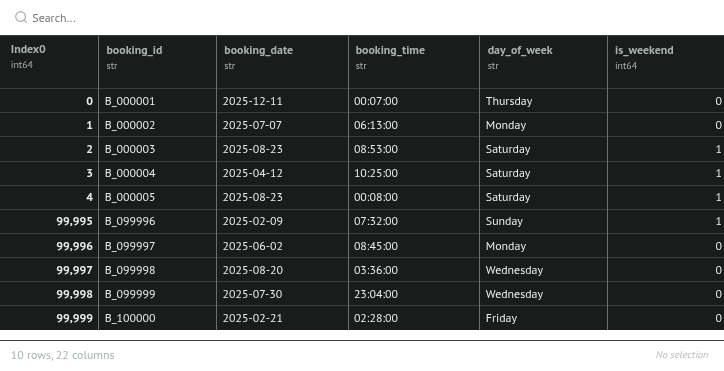

In [ ]:
pd.concat([bookings.head(5), bookings.tail(5)], ignore_index=False)

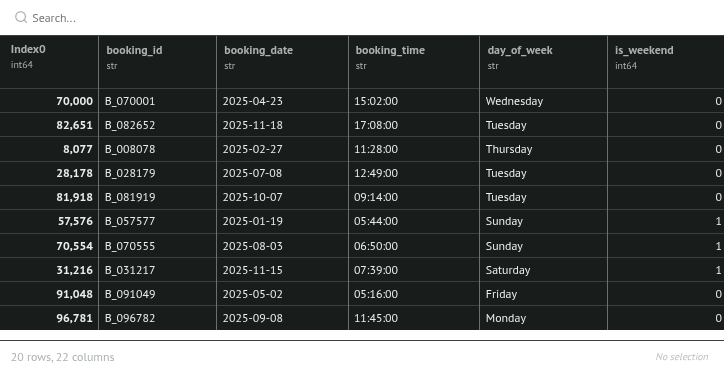

In [ ]:
bookings.sample(n=20, ignore_index=False, random_state=55)

classify colunms to id, num and str groups

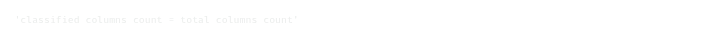

In [ ]:
bookings_id_cols, bookings_num_cols, bookings_str_cols, _is_match  = classify_columns(bookings)
_is_match

In [ ]:
bookings_id_cols, bookings_num_cols, bookings_str_cols

## stats look at nums attrbs

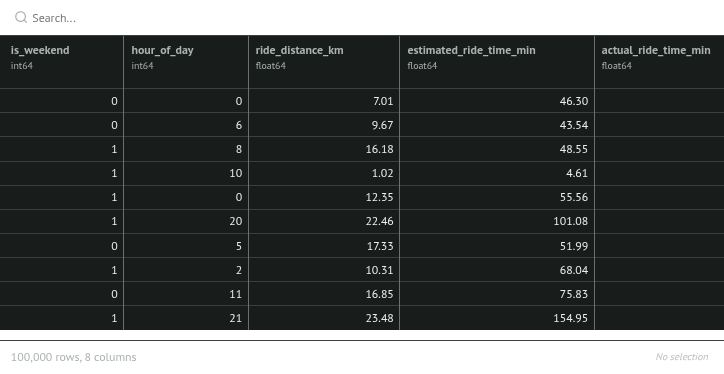

In [ ]:
bookings[bookings_num_cols]

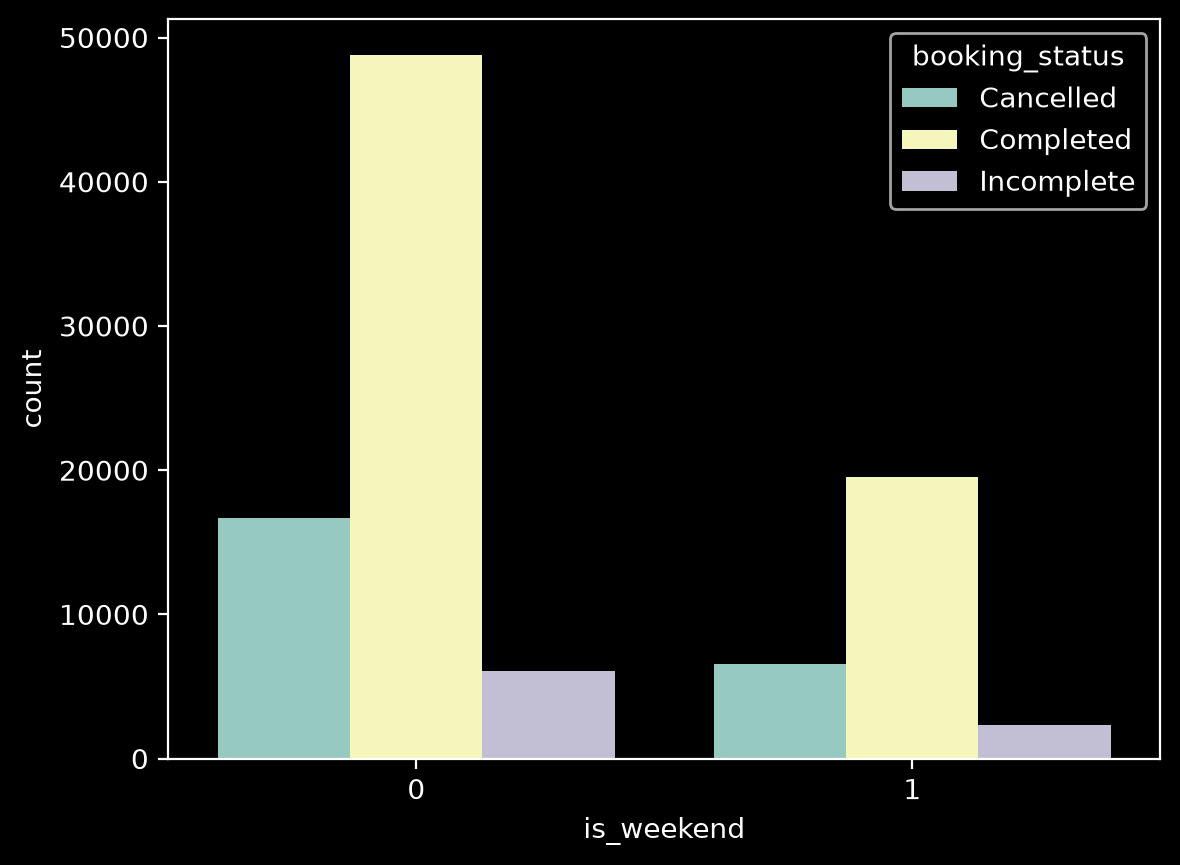

In [ ]:
# Count Plot (most used in EDA)
sns.countplot(data=bookings, x='is_weekend', hue="booking_status")

# With target hue (powerful)
# sns.countplot(data=df, x='department', hue='target')

# Horizontal for many categories
# sns.countplot(data=df, y='job_title')

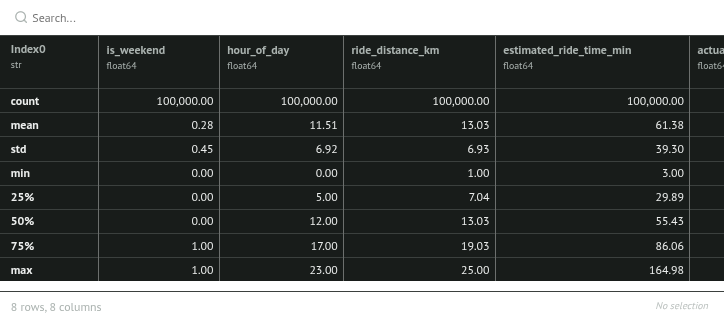

In [ ]:
bookings.describe().round(2)

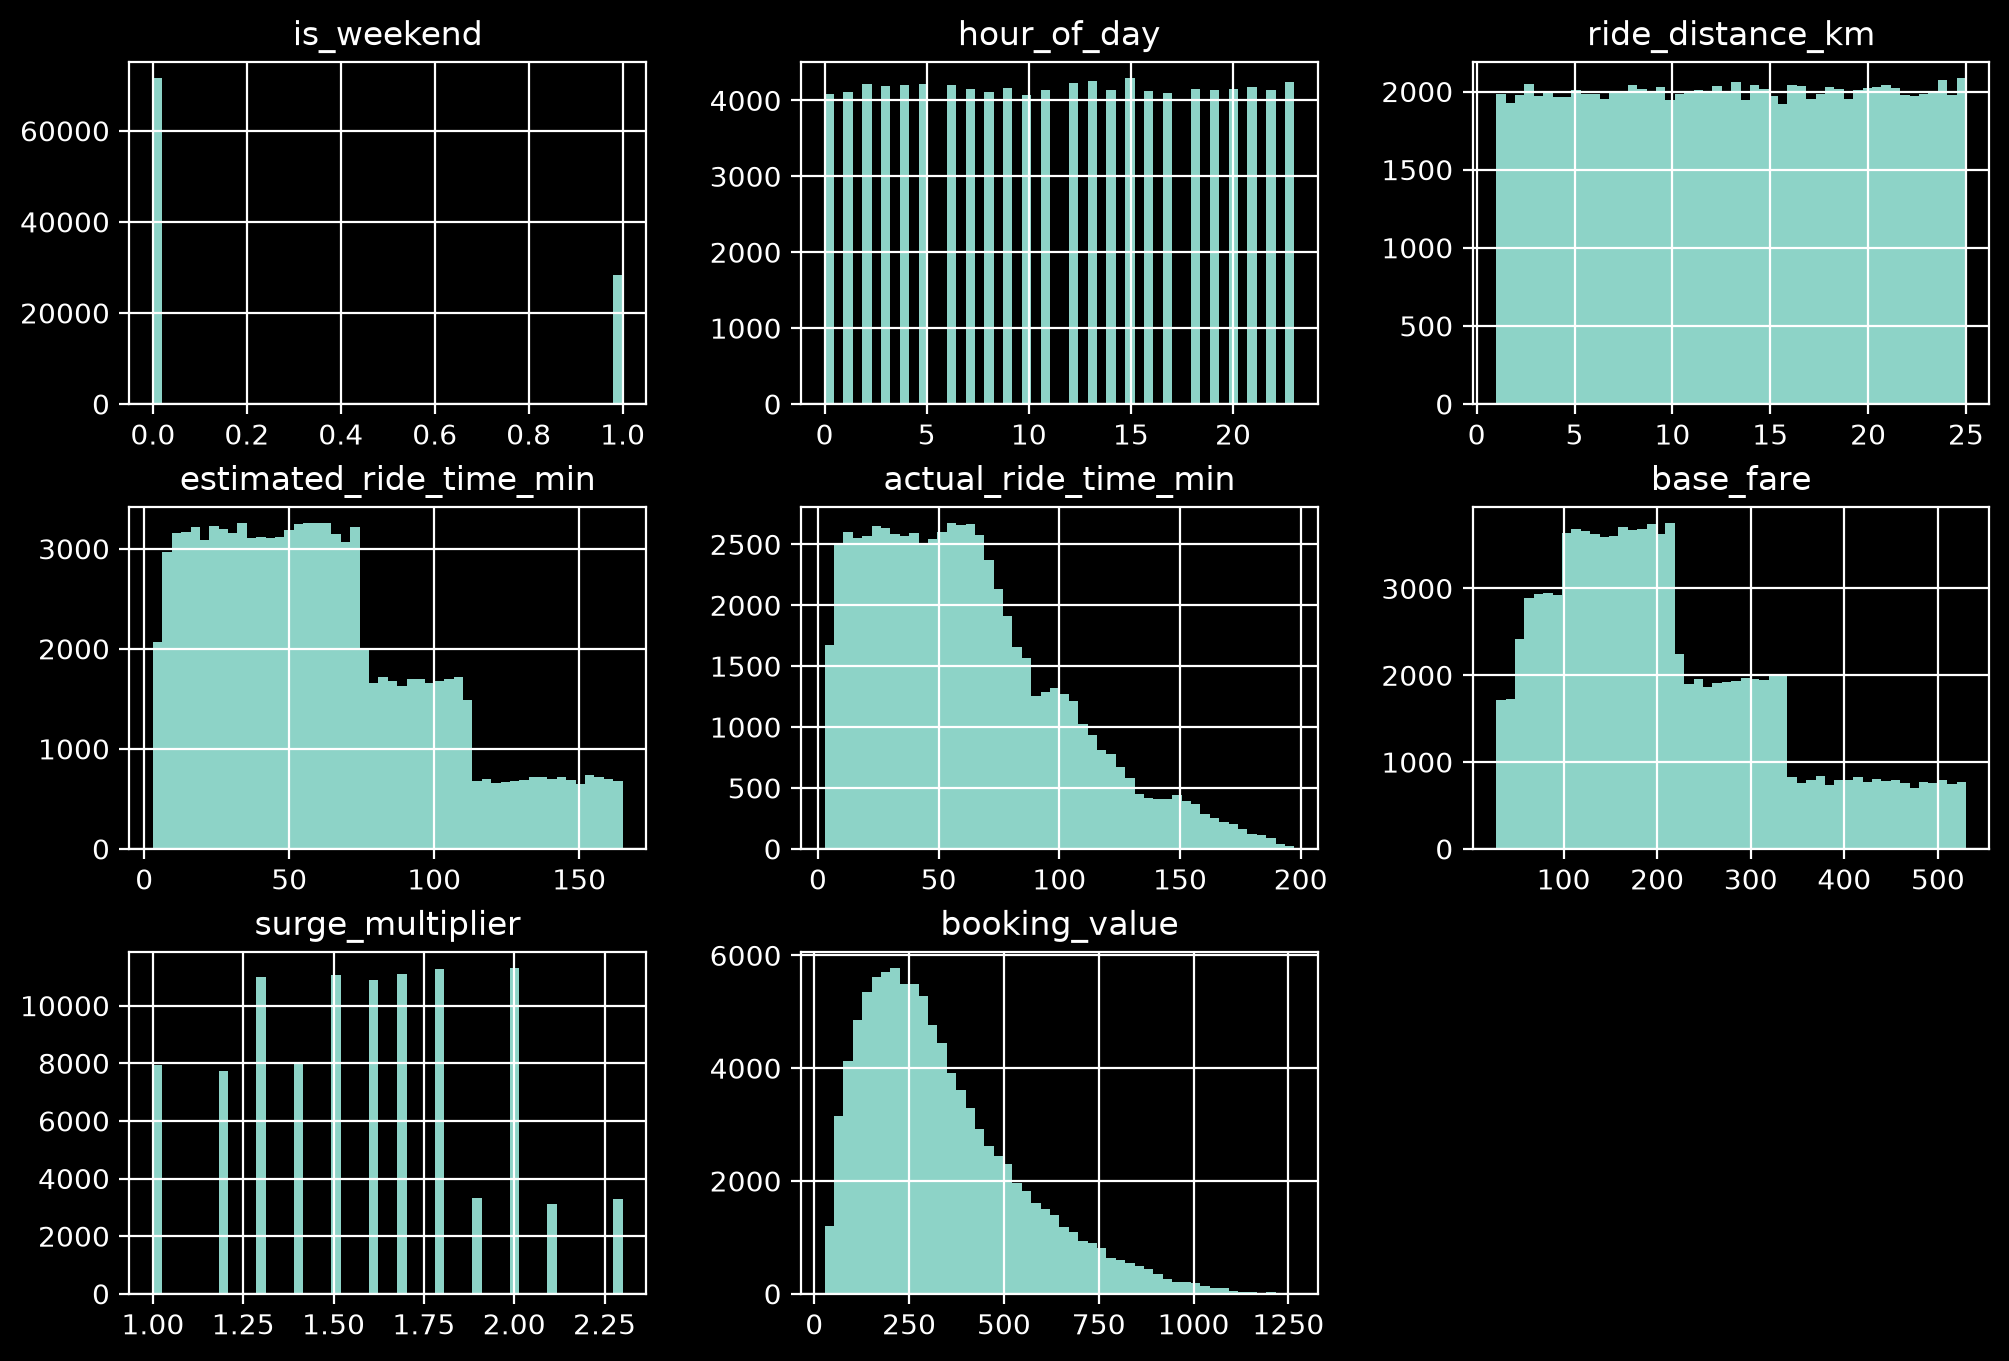

In [ ]:
bookings.hist(bins=50, figsize=(12, 8))
plt.show()

## stats look at strs attrbs

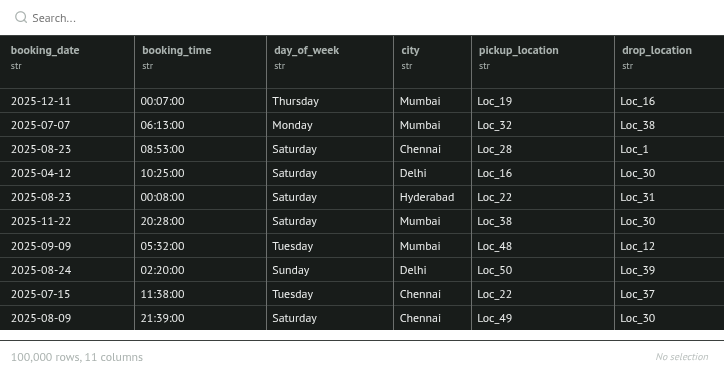

In [ ]:
bookings[bookings_str_cols]

In [ ]:
bookings_str_cols

In [ ]:
initial_inspect_str_attr(bookings,"booking_date")

In [ ]:
initial_inspect_str_attr(bookings, "booking_time")

In [ ]:
initial_inspect_str_attr(bookings, "day_of_week")

In [ ]:
initial_inspect_str_attr(bookings, "city")

In [ ]:
initial_inspect_str_attr(bookings, "pickup_location")

In [ ]:
initial_inspect_str_attr(bookings, "drop_location")

In [ ]:
initial_inspect_str_attr(bookings, "vehicle_type")

In [ ]:
initial_inspect_str_attr(bookings, "traffic_level")

In [ ]:
initial_inspect_str_attr(bookings, "weather_condition")

In [ ]:
initial_inspect_str_attr(bookings, "booking_status")

In [ ]:
initial_inspect_str_attr(bookings, "incomplete_ride_reason")

## stats look at ids attrbs

In [ ]:
bookings_id_cols

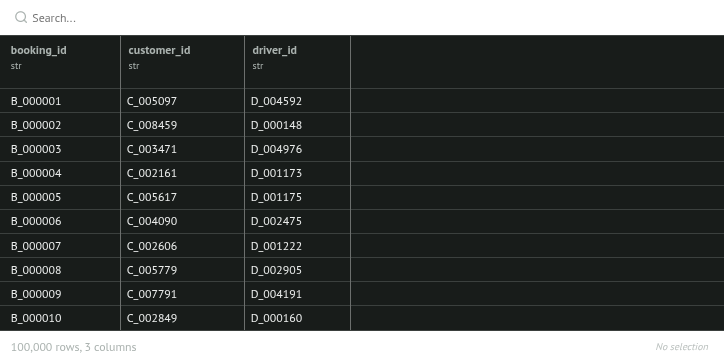

In [ ]:
bookings[bookings_id_cols]

In [ ]:
validate_identifier_columns(bookings, bookings_id_cols)

booking_id: has no null values
booking_id: all values are unique
customer_id: has no null values
customer_id: values are not unique
driver_id: has no null values
driver_id: values are not unique


# Quick look at Customers.csv

## overview of df only

In [ ]:
# load customer file
customers = pd.read_csv(customers_path)

In [ ]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  str    
 1   customer_gender           10000 non-null  str    
 2   customer_age              10000 non-null  int64  
 3   customer_city             10000 non-null  str    
 4   customer_signup_days_ago  10000 non-null  int64  
 5   preferred_vehicle_type    10000 non-null  str    
 6   total_bookings            10000 non-null  int64  
 7   completed_rides           10000 non-null  int64  
 8   cancelled_rides           10000 non-null  int64  
 9   incomplete_rides          10000 non-null  int64  
 10  cancellation_rate         10000 non-null  float64
 11  avg_customer_rating       10000 non-null  float64
 12  customer_cancel_flag      10000 non-null  int64  
dtypes: float64(2), int64(7), str(4)
memory usage: 1015.8 KB


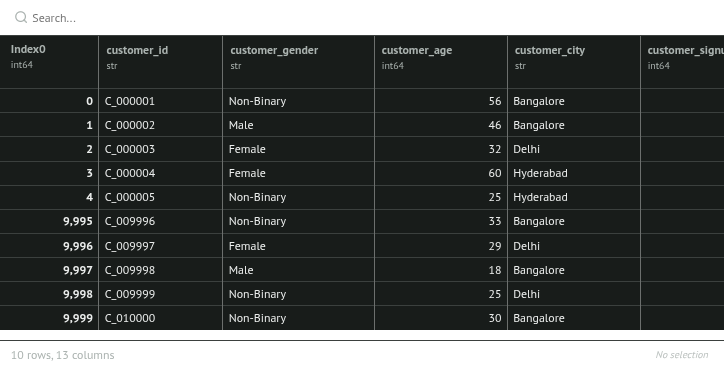

In [ ]:
pd.concat([customers.head(5), customers.tail(5)], ignore_index=False)

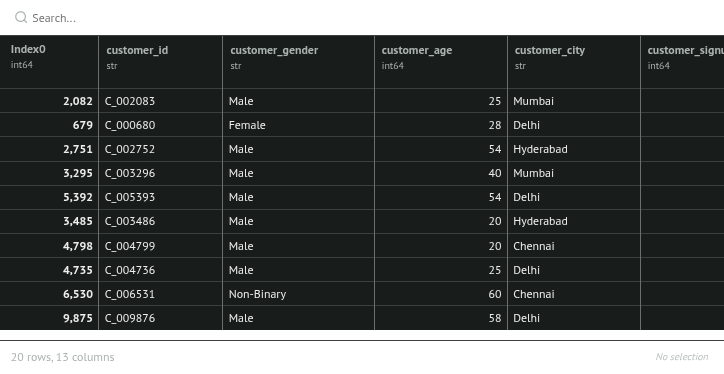

In [ ]:
customers.sample(n=20, ignore_index=False, random_state=55)

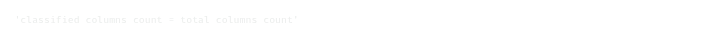

In [ ]:
customers_id_cols, customers_num_cols, customers_str_cols, _is_match  = classify_columns(customers)
_is_match

In [ ]:
customers_id_cols, customers_num_cols, customers_str_cols

## stats look at nums attrbs

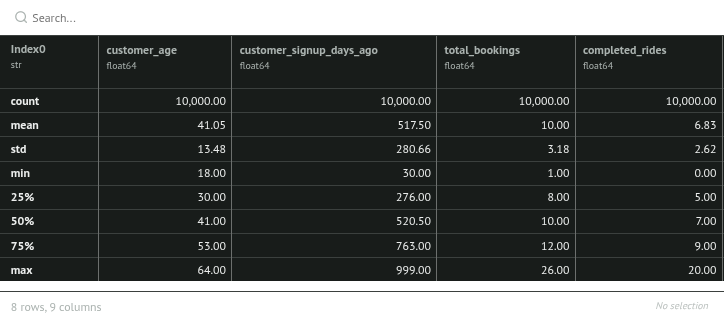

In [ ]:
customers.describe().round(2)

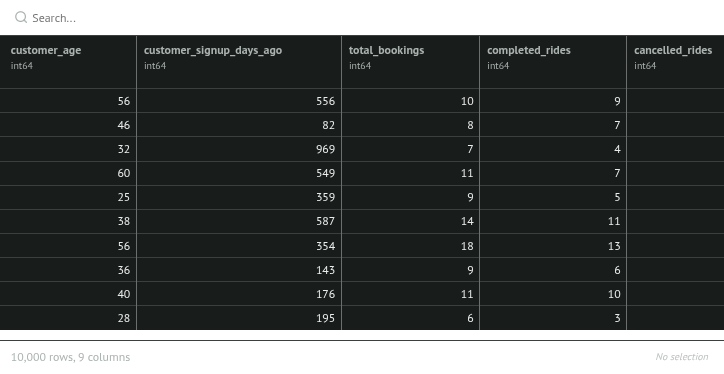

In [ ]:
customers[customers_num_cols]

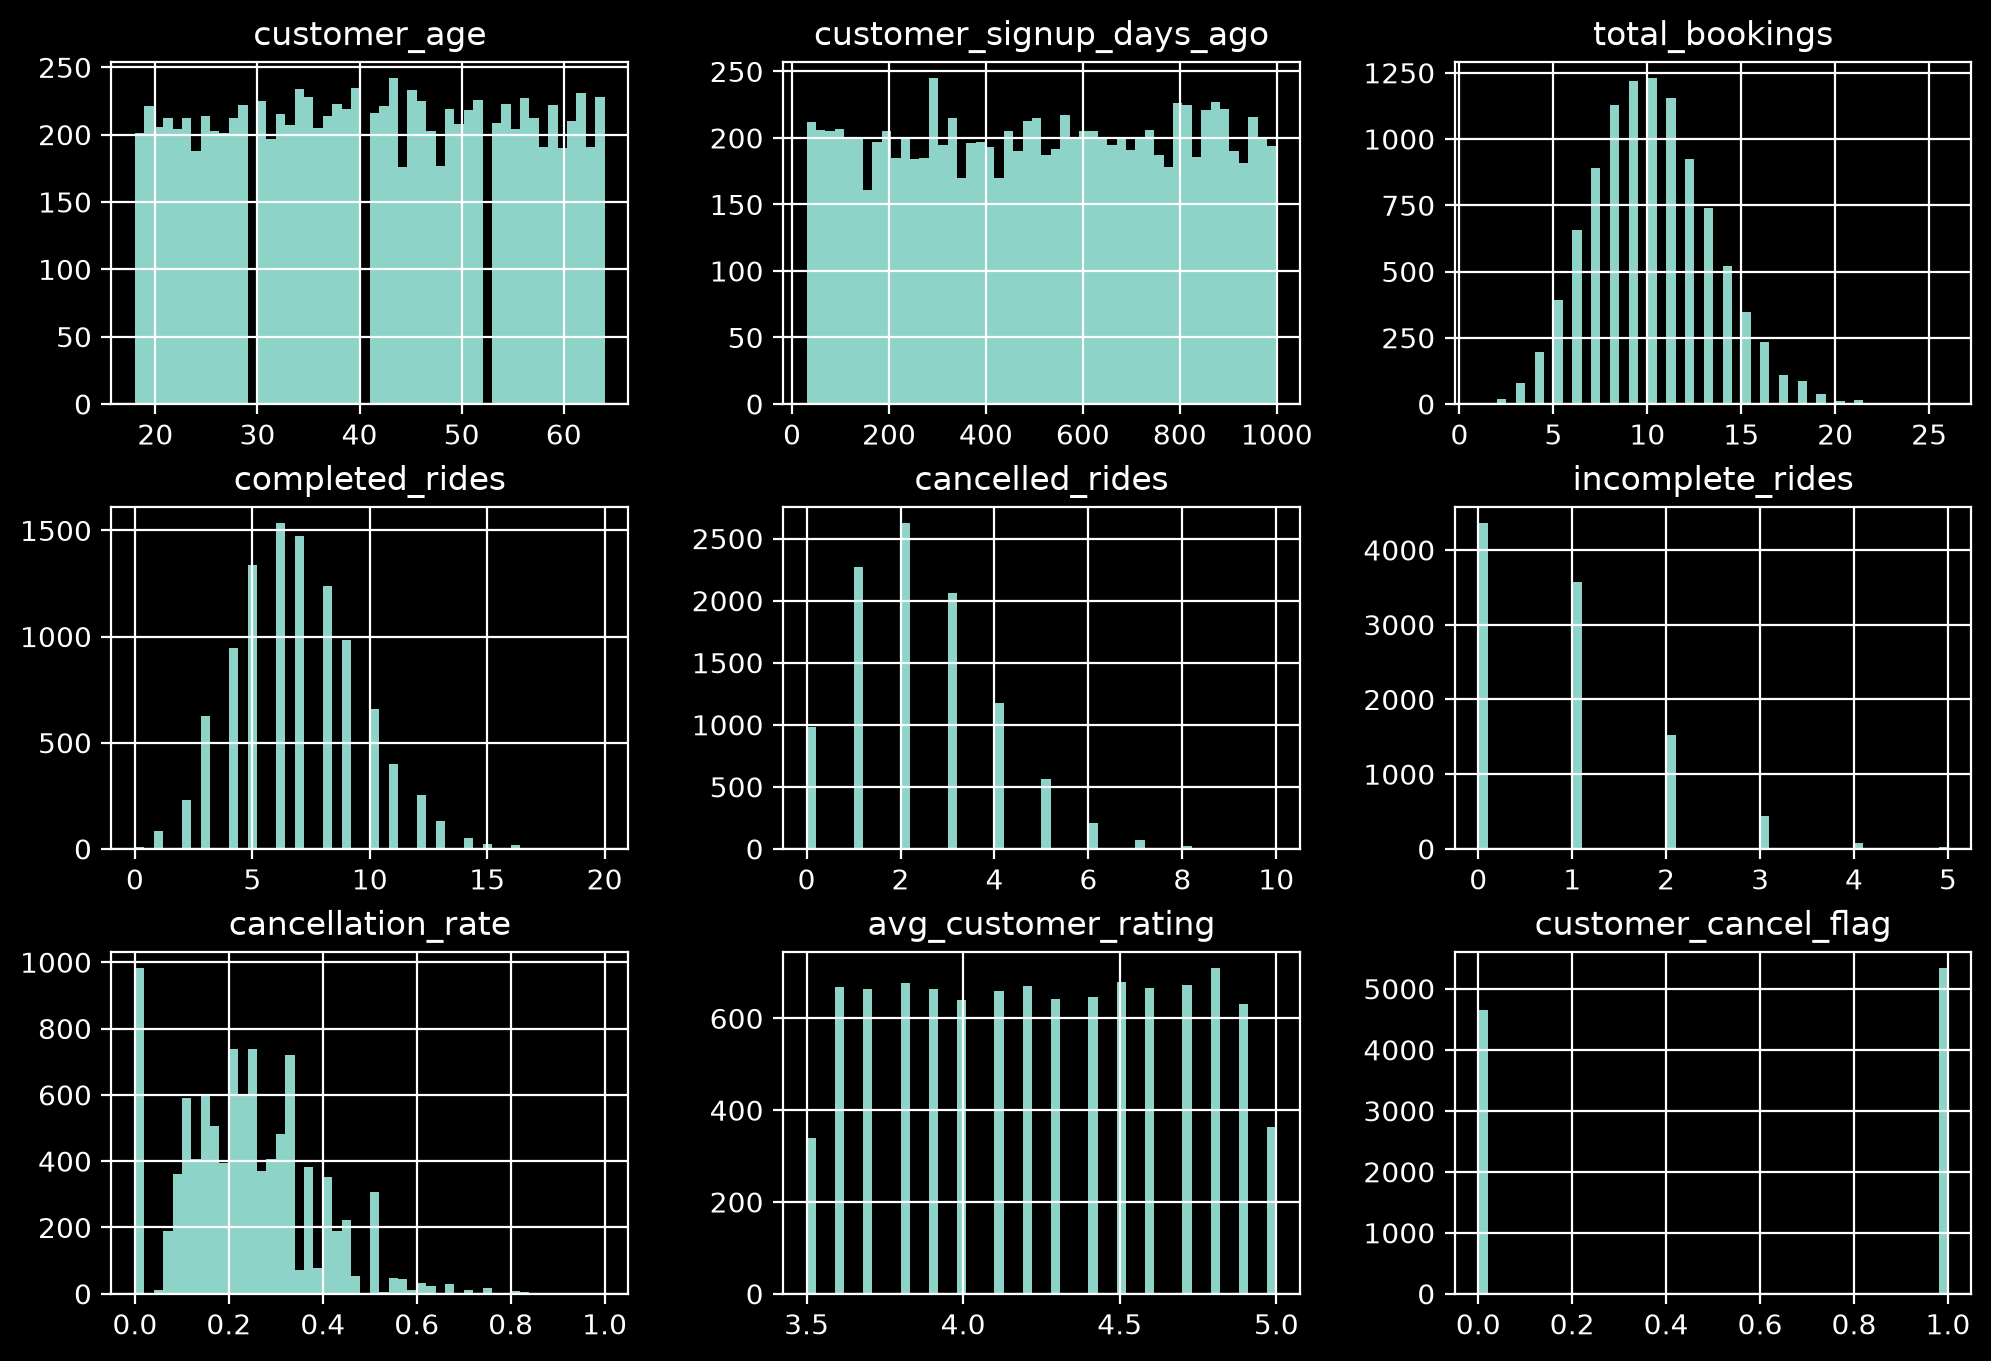

In [ ]:
customers.hist(bins=50, figsize=(12, 8))
plt.show()

## stats look at strs attrbs

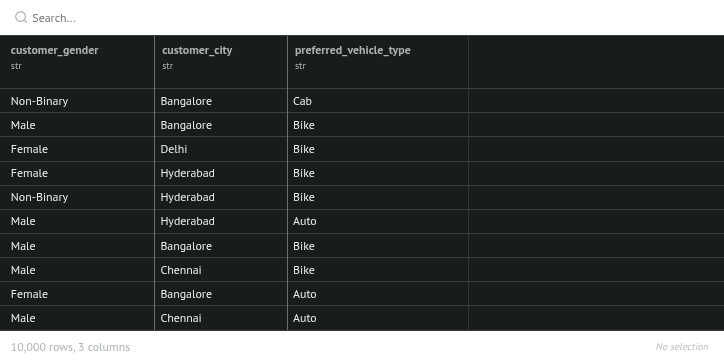

In [ ]:
customers[customers_str_cols]

In [ ]:
customers_str_cols

In [ ]:
initial_inspect_str_attr(customers, "customer_gender")

In [ ]:
initial_inspect_str_attr(customers, "customer_city")

In [ ]:
initial_inspect_str_attr(customers, "preferred_vehicle_type")

## stats look at ids attrbs

In [ ]:
customers_id_cols

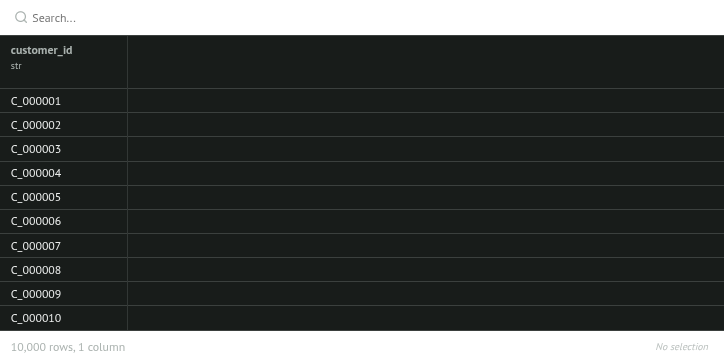

In [ ]:
customers[customers_id_cols]

In [ ]:
validate_identifier_columns(customers, customers_id_cols)

customer_id: has no null values
customer_id: all values are unique


# Quick look at drivers.csv

## overview of df only

In [ ]:
# load drivers file
drivers = pd.read_csv(drivers_path)

In [ ]:
drivers.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   driver_id                5000 non-null   str    
 1   driver_age               5000 non-null   int64  
 2   driver_city              5000 non-null   str    
 3   vehicle_type             5000 non-null   str    
 4   driver_experience_years  5000 non-null   int64  
 5   total_assigned_rides     5000 non-null   int64  
 6   accepted_rides           5000 non-null   int64  
 7   incomplete_rides         5000 non-null   int64  
 8   delay_count              5000 non-null   int64  
 9   acceptance_rate          5000 non-null   float64
 10  delay_rate               5000 non-null   float64
 11  avg_driver_rating        5000 non-null   float64
 12  avg_pickup_delay_min     5000 non-null   float64
 13  driver_delay_flag        5000 non-null   int64  
dtypes: float64(4), int64(7), str(3)
mem

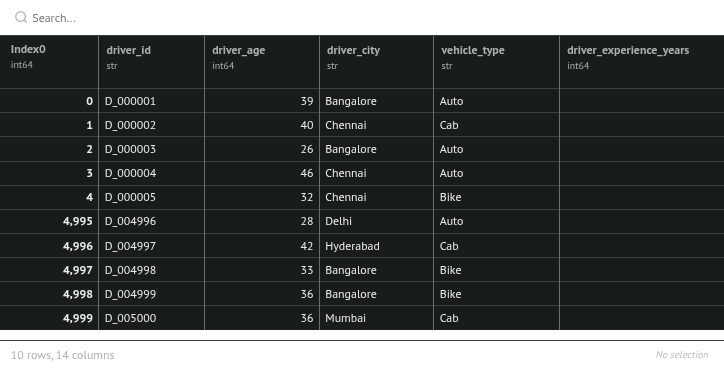

In [ ]:
pd.concat([drivers.head(5), drivers.tail(5)], ignore_index=False)

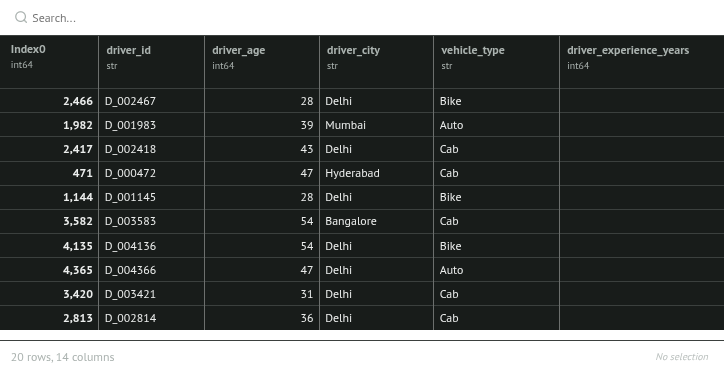

In [ ]:
drivers.sample(n=20, ignore_index=False, random_state=55)

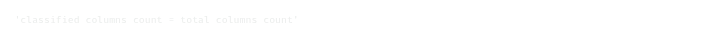

In [ ]:
drivers_id_cols, drivers_num_cols, drivers_str_cols, _is_match  = classify_columns(drivers)
_is_match

In [ ]:
drivers_id_cols, drivers_num_cols, drivers_str_cols

## stats look at nums attrbs

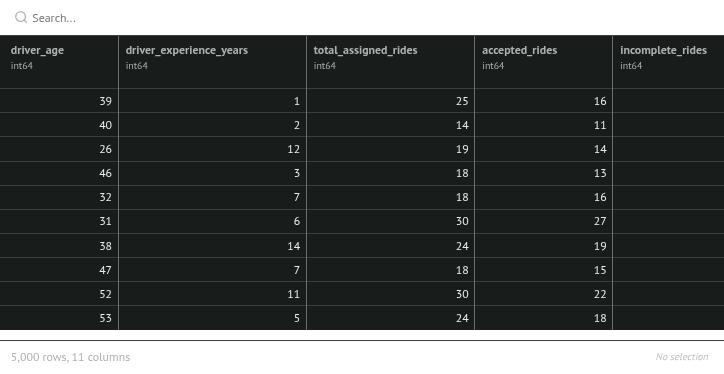

In [ ]:
drivers[drivers_num_cols]

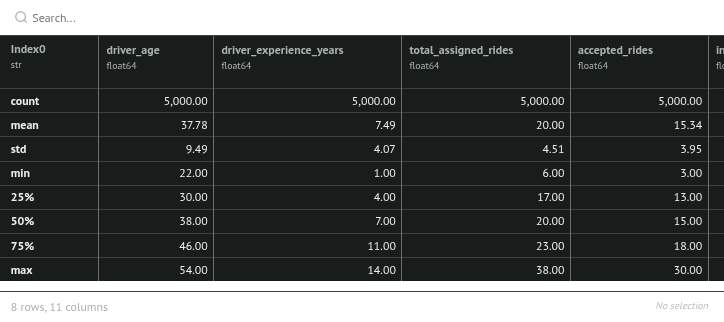

In [ ]:
drivers.describe().round(2)

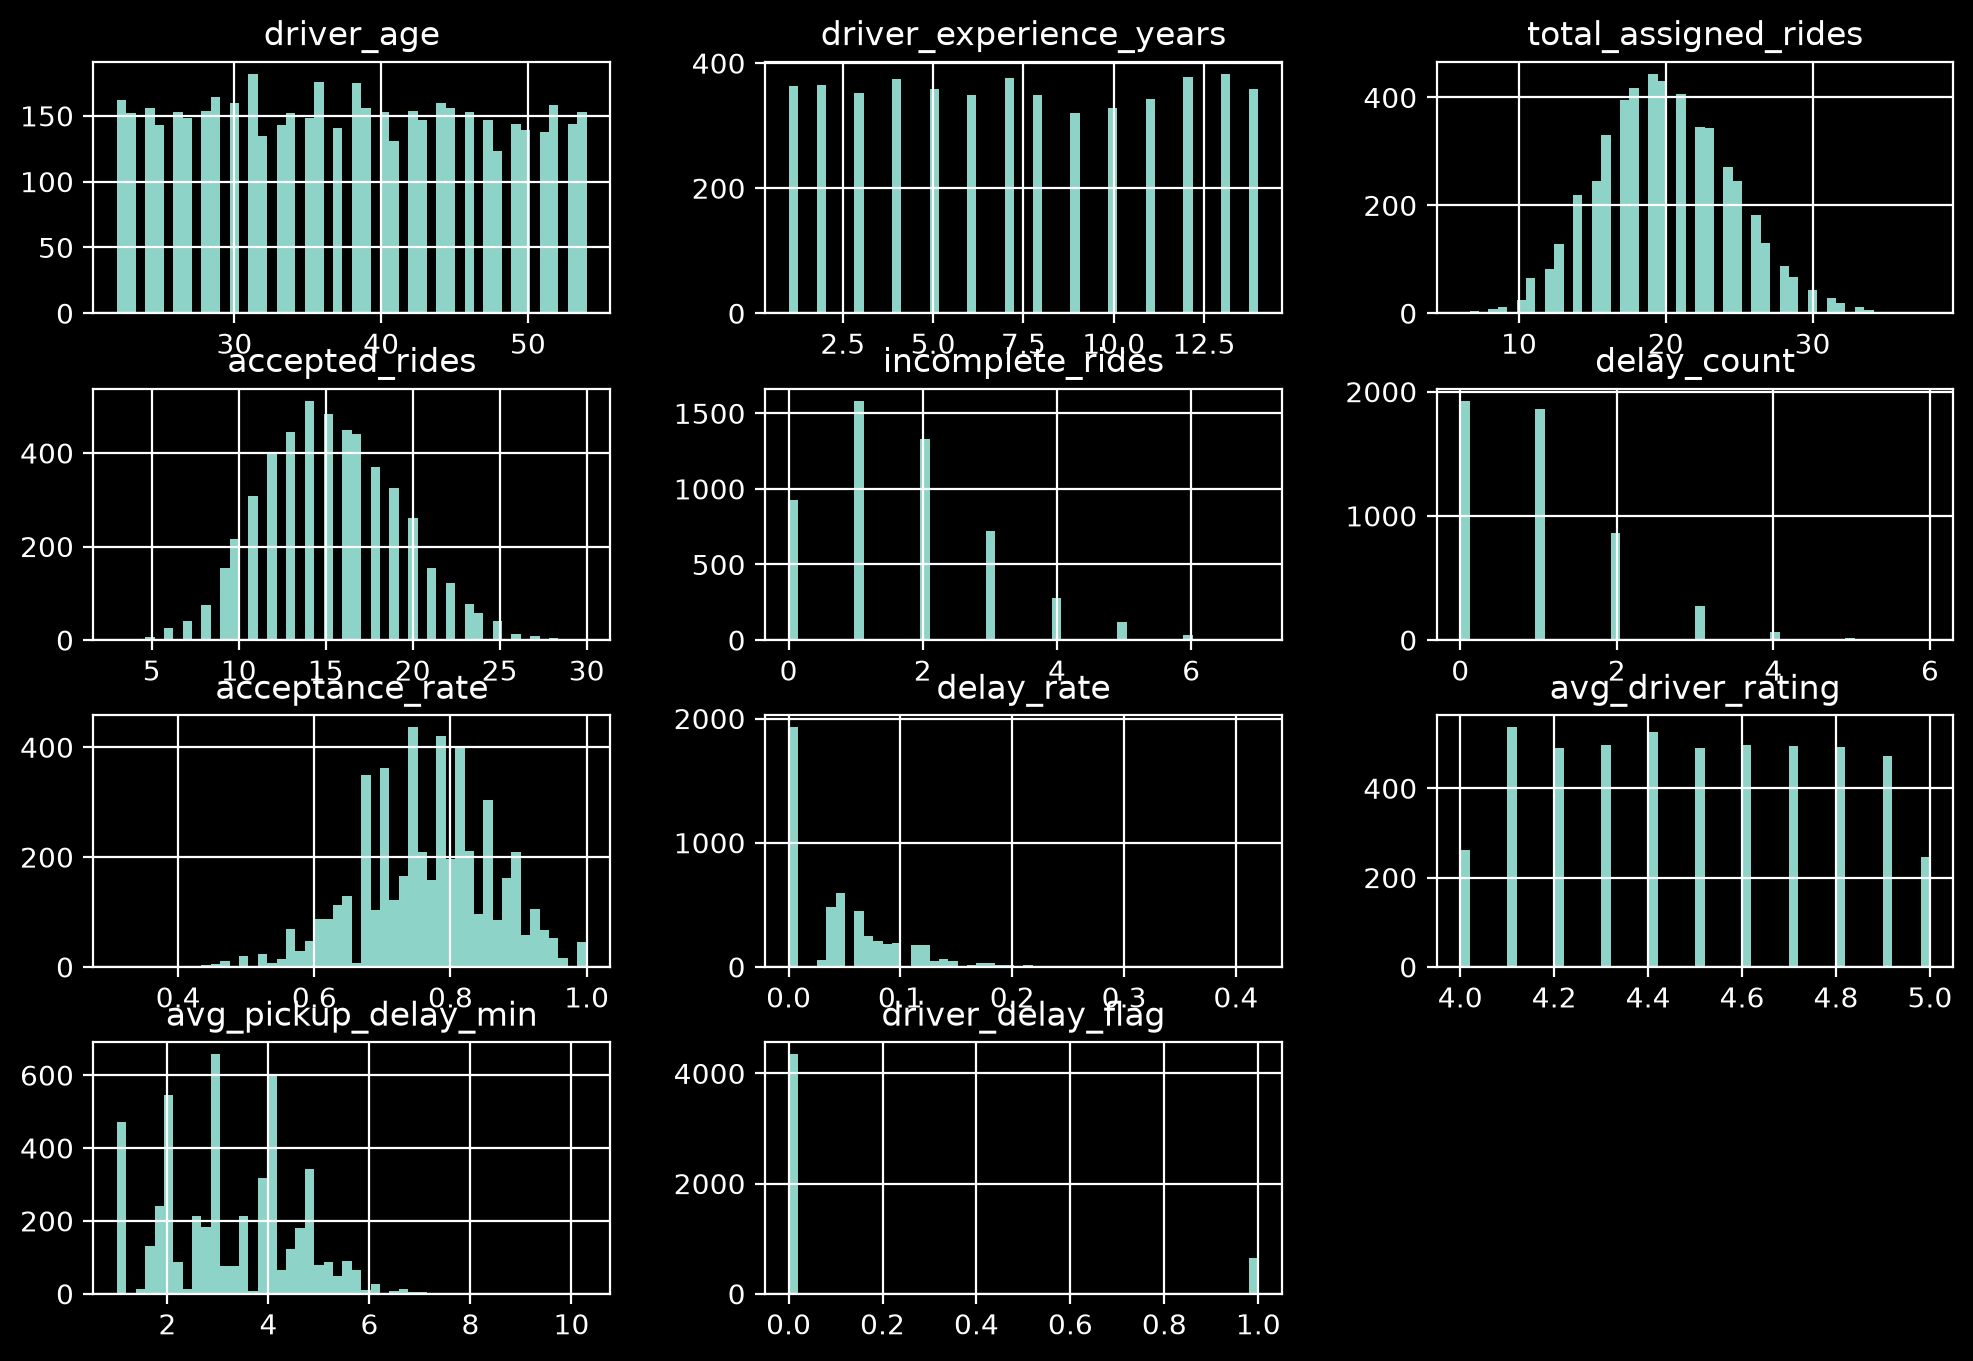

In [ ]:
drivers.hist(bins=50, figsize=(12, 8))
plt.show()

## stats look at strs attrbs

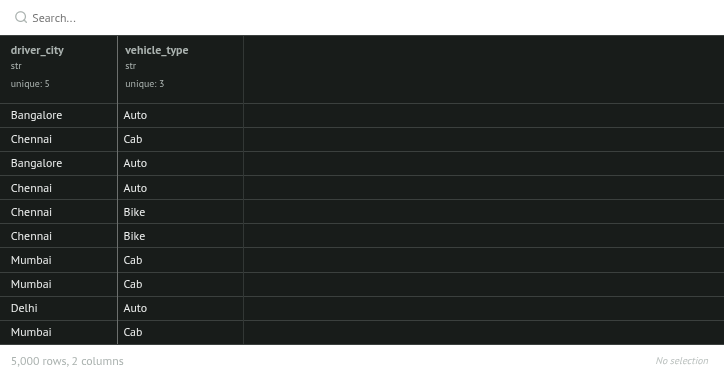

In [ ]:
drivers[drivers_str_cols]

In [ ]:
drivers_str_cols

In [ ]:
initial_inspect_str_attr(drivers, "driver_city")

In [ ]:
initial_inspect_str_attr(drivers, "vehicle_type")

## stats look at ids attrbs

In [ ]:
drivers_id_cols

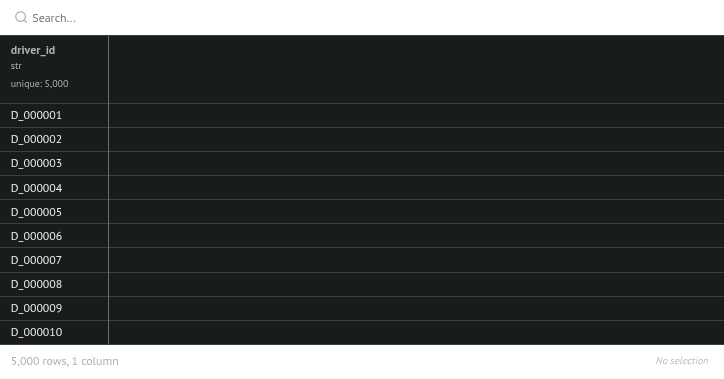

In [ ]:
drivers[drivers_id_cols]

In [ ]:
validate_identifier_columns(drivers, drivers_id_cols)

driver_id: has no null values
driver_id: all values are unique


# Quick look at location_demand.csv

## overview of df only

In [ ]:
# load location demand file
loc_demand = pd.read_csv(location_demand_path)

In [ ]:
loc_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 17941 entries, 0 to 17940
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  17941 non-null  str    
 1   pickup_location       17941 non-null  str    
 2   hour_of_day           17941 non-null  int64  
 3   vehicle_type          17941 non-null  str    
 4   total_requests        17941 non-null  int64  
 5   completed_rides       17941 non-null  int64  
 6   cancelled_rides       17941 non-null  int64  
 7   avg_wait_time_min     17941 non-null  float64
 8   avg_surge_multiplier  17941 non-null  float64
 9   demand_level          17941 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 1.4 MB


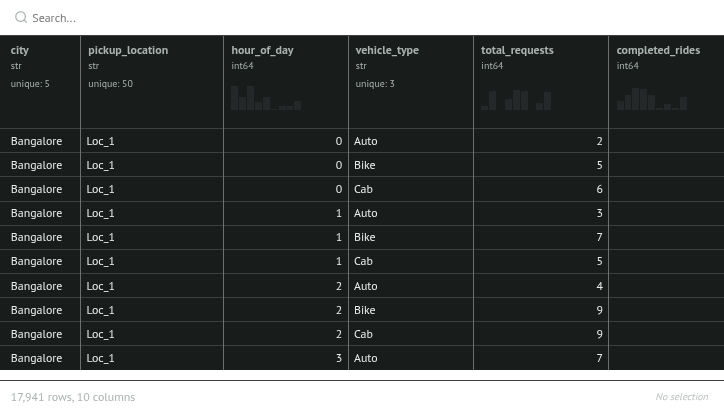

In [ ]:
loc_demand

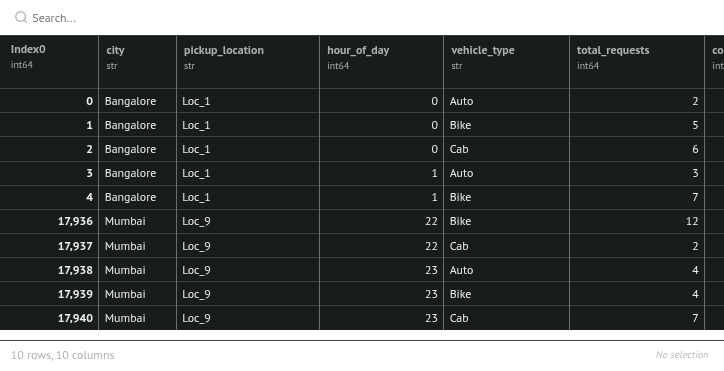

In [ ]:
pd.concat([loc_demand.head(5), loc_demand.tail(5)], ignore_index=False)

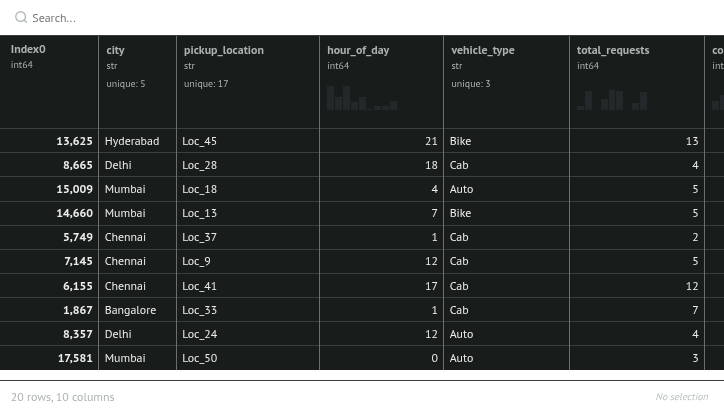

In [ ]:
loc_demand.sample(n=20, ignore_index=False, random_state=55)

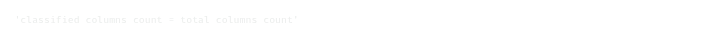

In [ ]:
loc_demand_id_cols, loc_demand_num_cols, loc_demand_str_cols, _is_match  = classify_columns(loc_demand)
_is_match

In [ ]:
loc_demand_id_cols, loc_demand_num_cols, loc_demand_str_cols

## stats look at nums attrbs

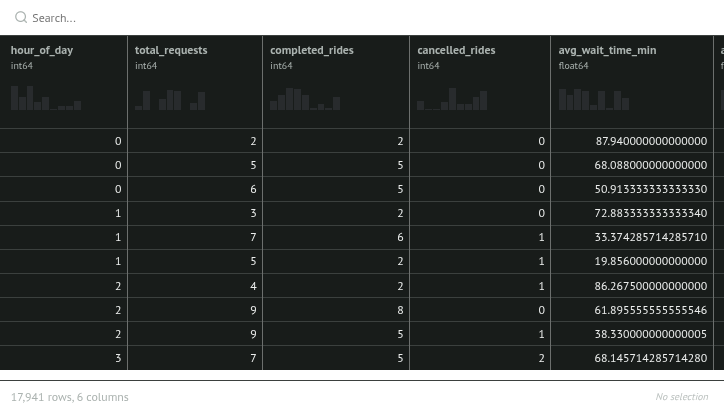

In [ ]:
loc_demand[loc_demand_num_cols]

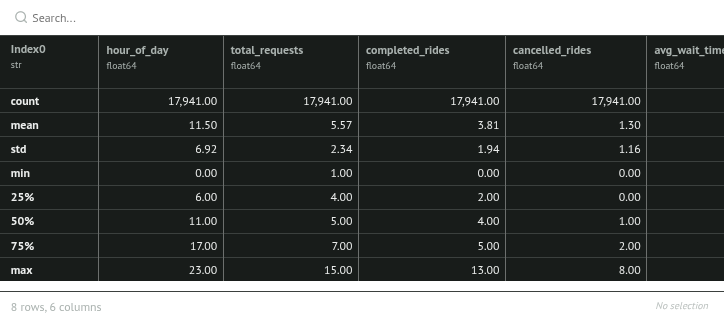

In [ ]:
loc_demand.describe().round(2)

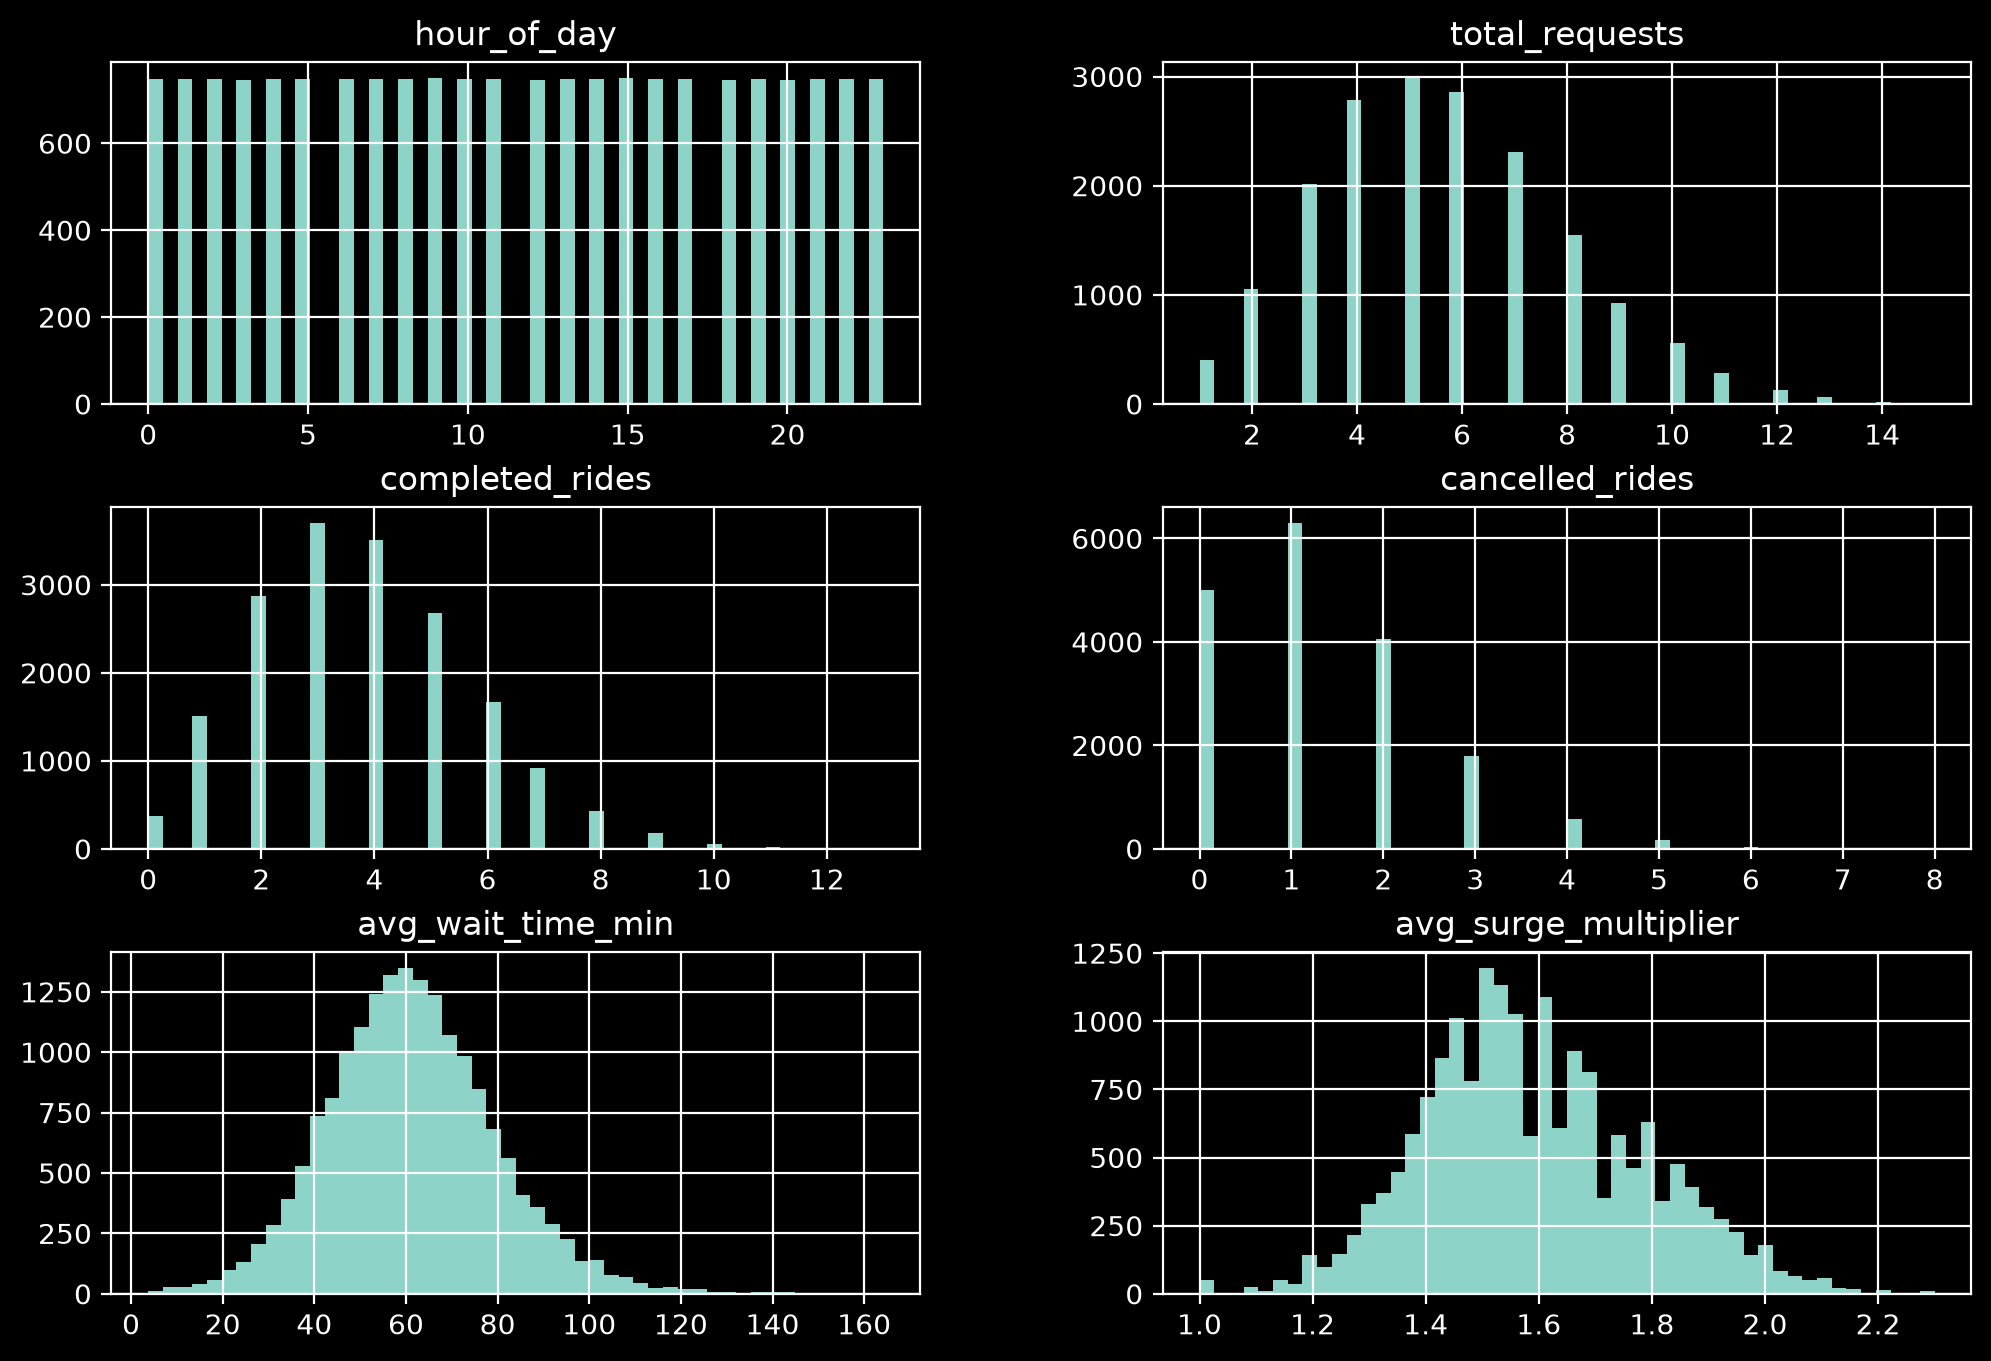

In [ ]:
loc_demand.hist(bins=50, figsize=(12, 8))
plt.show()

## stats look at strs attrbs

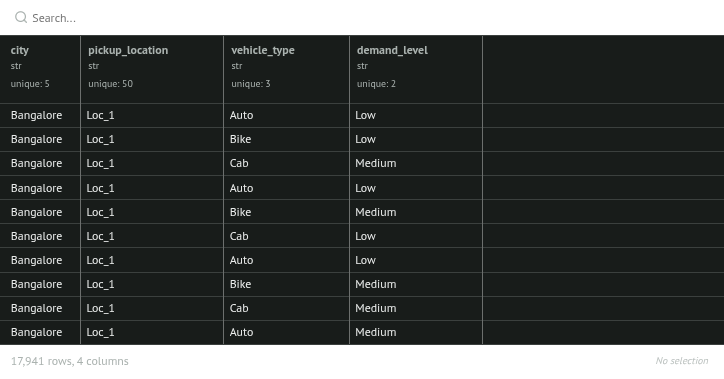

In [ ]:
loc_demand[loc_demand_str_cols]

In [ ]:
loc_demand_str_cols

In [ ]:
initial_inspect_str_attr(loc_demand, "city")

In [ ]:
initial_inspect_str_attr(loc_demand, "pickup_location")

In [ ]:
initial_inspect_str_attr(loc_demand, "vehicle_type")

In [ ]:
initial_inspect_str_attr(loc_demand, "demand_level")

## stats look at ids attrbs

In [ ]:
loc_demand_id_cols

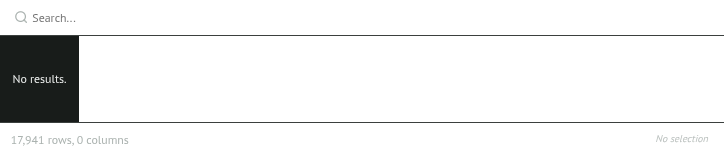

In [ ]:
loc_demand[loc_demand_id_cols]

In [ ]:
validate_identifier_columns(loc_demand, loc_demand_id_cols)

id_columns is empty


# Quick look at time_features.csv

## overview of df only

In [ ]:
# load bookings file
time_feat = pd.read_csv(time_features_path)

In [ ]:
time_feat.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   datetime        8760 non-null   str  
 1   hour_of_day     8760 non-null   int64
 2   day_of_week     8760 non-null   str  
 3   is_weekend      8760 non-null   int64
 4   is_holiday      8760 non-null   int64
 5   peak_time_flag  8760 non-null   int64
 6   season          8760 non-null   str  
dtypes: int64(4), str(3)
memory usage: 479.2 KB


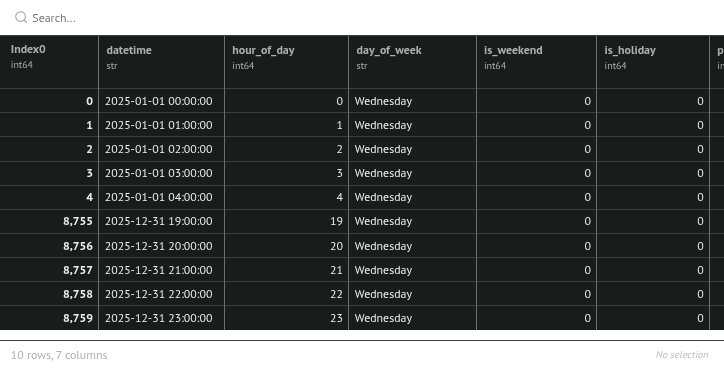

In [ ]:
pd.concat([time_feat.head(5), time_feat.tail(5)], ignore_index=False)

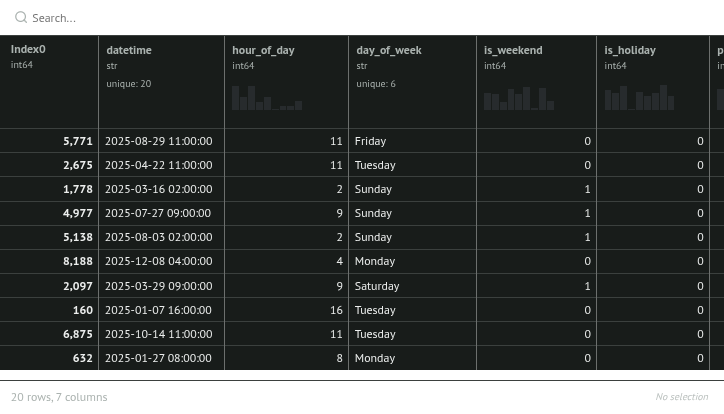

In [ ]:
time_feat.sample(n=20, ignore_index=False, random_state=55)

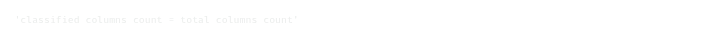

In [ ]:
time_feat_id_cols, time_feat_num_cols, time_feat_str_cols, _is_match  = classify_columns(time_feat)
_is_match

In [ ]:
time_feat_id_cols, time_feat_num_cols, time_feat_str_cols

## stats look at nums attrbs

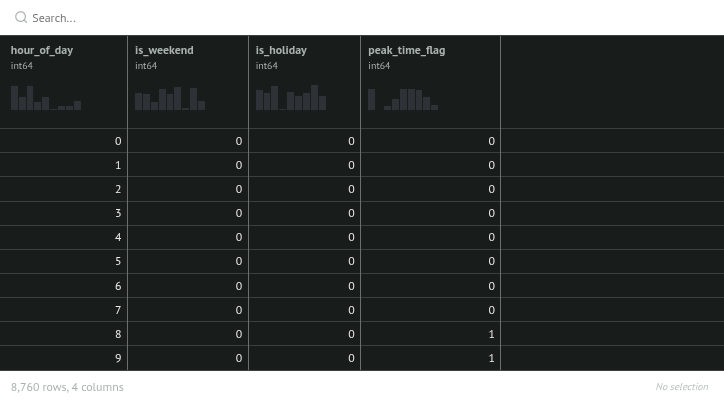

In [ ]:
time_feat[time_feat_num_cols]

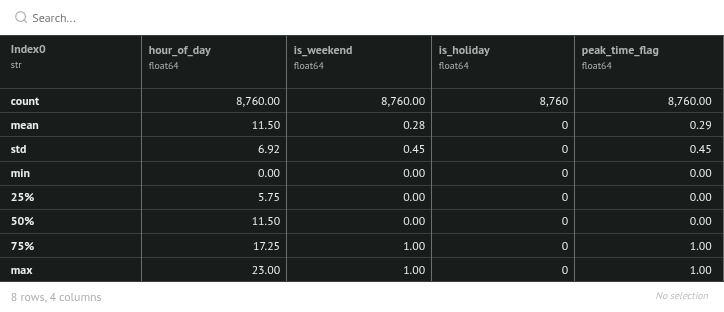

In [ ]:
time_feat.describe().round(2)

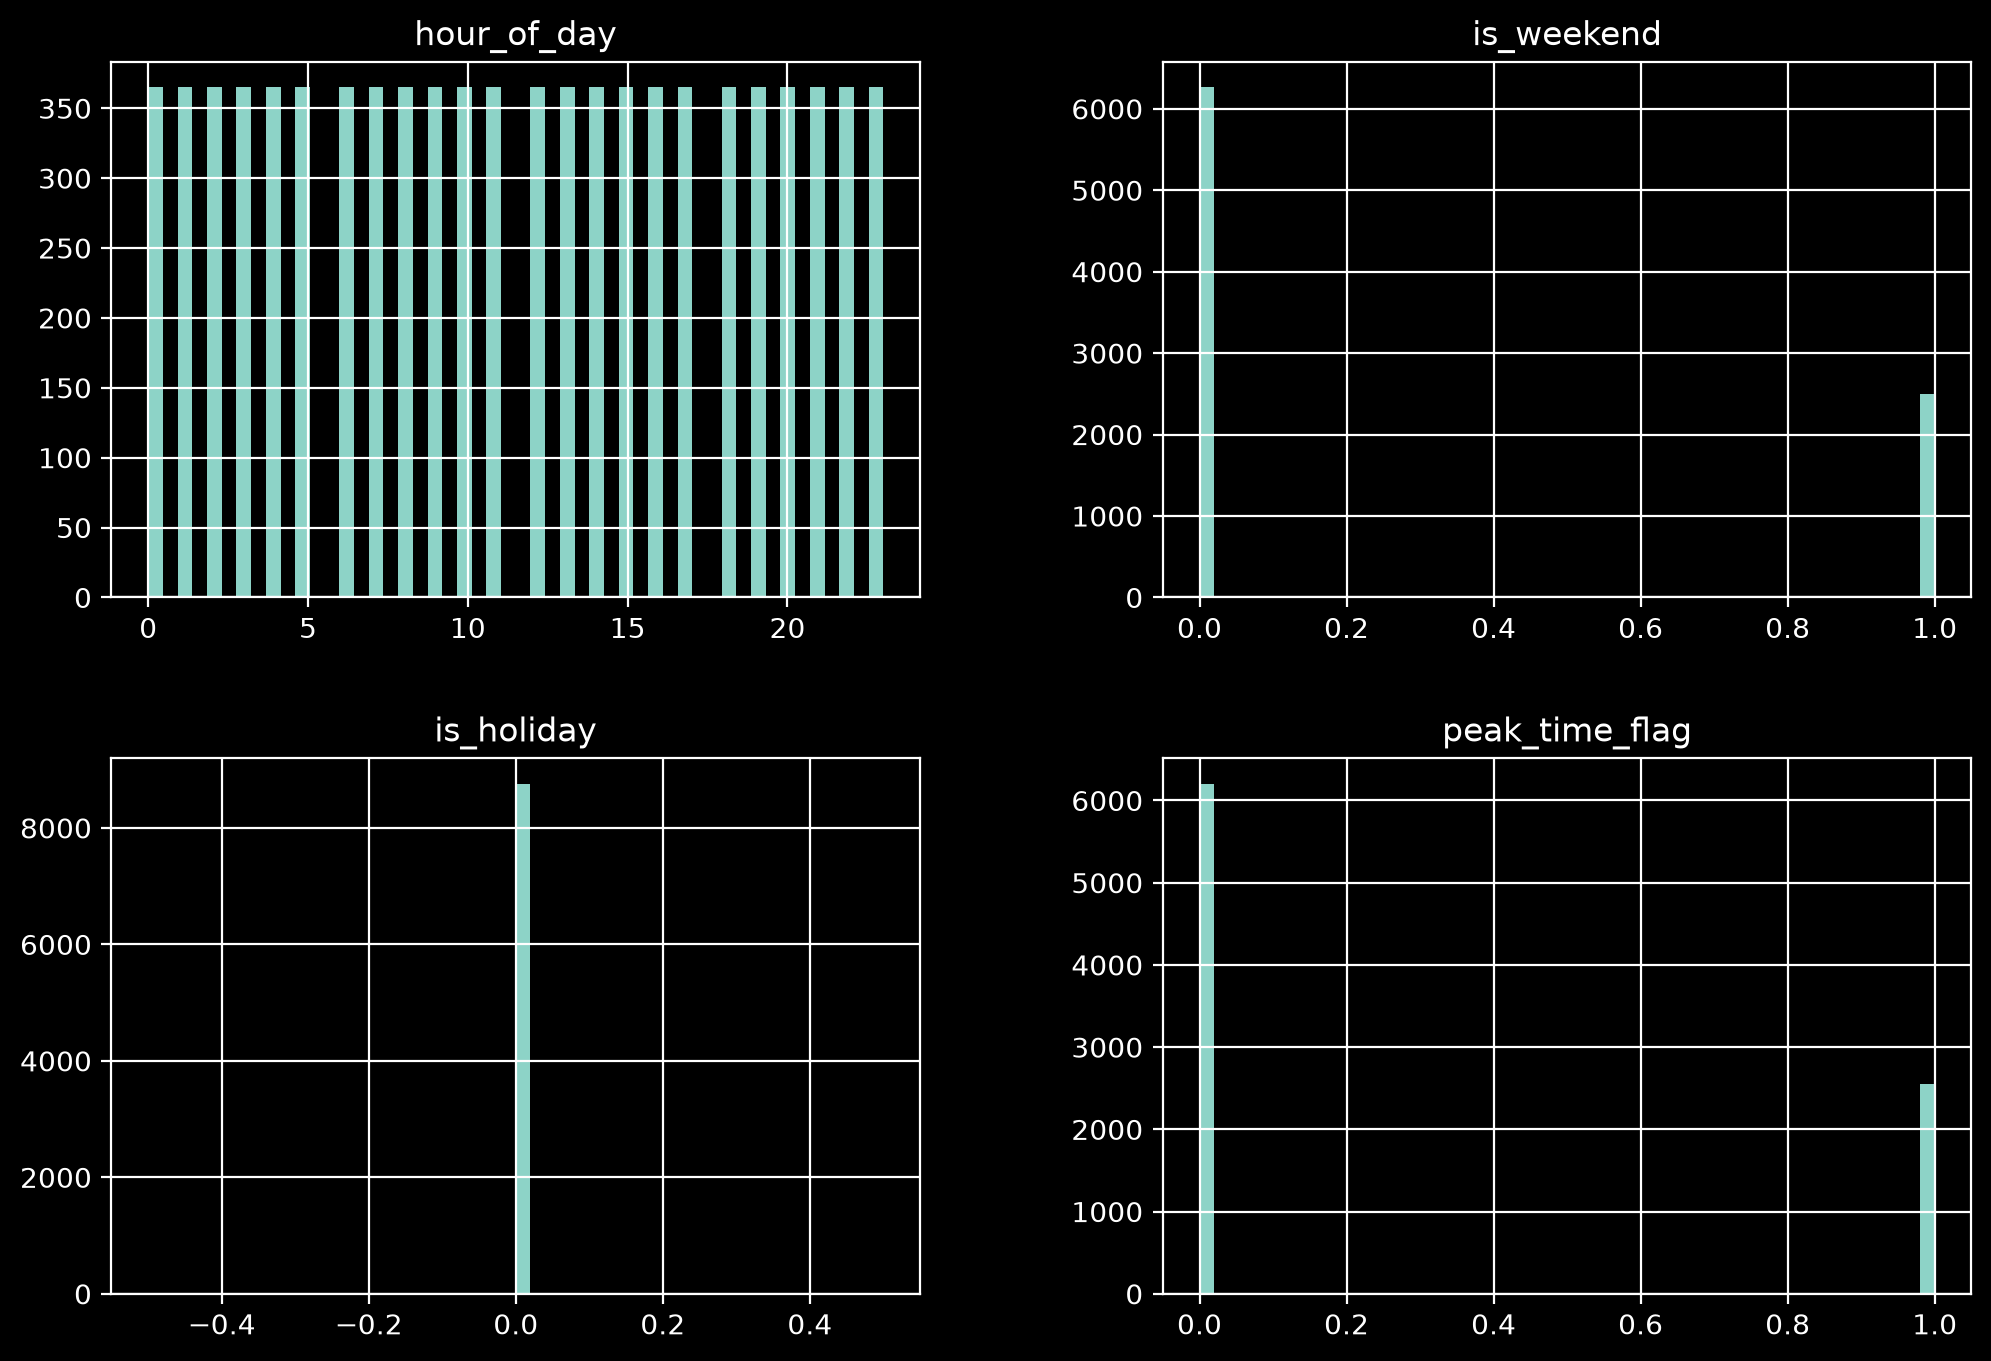

In [ ]:
time_feat.hist(bins=50, figsize=(12, 8))
plt.show()

## stats look at strs attrbs

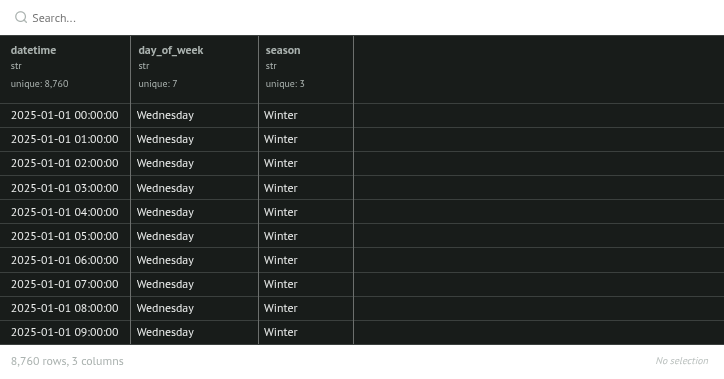

In [ ]:
time_feat[time_feat_str_cols]

In [ ]:
time_feat_str_cols

In [ ]:
# skipping this because it takes lots of time
# initial_inspect_str_attr(time_feat, "datetime")

In [ ]:
initial_inspect_str_attr(time_feat, "day_of_week")

In [ ]:
initial_inspect_str_attr(time_feat, "season")

## stats look at ids attrbs

In [ ]:
time_feat_id_cols

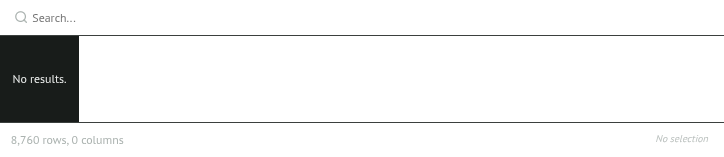

In [ ]:
time_feat[time_feat_id_cols]

In [ ]:
validate_identifier_columns(time_feat, time_feat_id_cols)

id_columns is empty
